<a href="https://colab.research.google.com/github/WajdAlsuhaymi/IT326-DataMining-Group2/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 – Data Summarization and Preprocessing

This phase focuses on analyzing and preparing the dataset before applying data mining techniques.
It includes summarizing data, visualizing relationships, handling missing values, and applying preprocessing techniques such as encoding, normalization, and outlier removal.

### **Part** 1 : Data Summarization

In [ ]:

# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Loading the Dataset
url='https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv'
df = pd.read_csv(url)
df.head()


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# General Information and Missing Values
print("Dataset Shape:", df.shape)
df.info()

# Missing values summary
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)


Dataset Shape: (2004, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2004 entries, 0 to 2003
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     1001 non-null   object 
 1   Age                         1001 non-null   object 
 2   Gender                      1000 non-null   object 
 3   Platform                    1000 non-null   object 
 4   Daily_Usage_Time (minutes)  1000 non-null   float64
 5   Posts_Per_Day               1000 non-null   float64
 6   Likes_Received_Per_Day      1000 non-null   float64
 7   Comments_Received_Per_Day   1000 non-null   float64
 8   Messages_Sent_Per_Day       1000 non-null   float64
 9   Dominant_Emotion            1000 non-null   object 
dtypes: float64(5), object(5)
memory usage: 156.7+ KB


,0
Platform,1004
Gender,1004
Likes_Received_Per_Day,1004
Comments_Received_Per_Day,1004
Daily_Usage_Time (minutes),1004
Posts_Per_Day,1004
Messages_Sent_Per_Day,1004
Dominant_Emotion,1004
Age,1003
User_ID,1003


In [ ]:
# Statistical Summary
df.describe().T  # Includes five-number summary for numeric columns


,count,mean,std,min,25%,50%,75%,max
Daily_Usage_Time (minutes),1000.0,95.950,38.850442,40.0,65.00,85.0,120.0,200.0
Posts_Per_Day,1000.0,3.321,1.914582,1.0,2.00,3.0,4.0,8.0
Likes_Received_Per_Day,1000.0,39.898,26.393867,5.0,20.00,33.0,55.0,110.0
Comments_Received_Per_Day,1000.0,15.611,8.819493,2.0,8.00,14.0,22.0,40.0
Messages_Sent_Per_Day,1000.0,22.560,8.516274,8.0,17.75,22.0,28.0,50.0


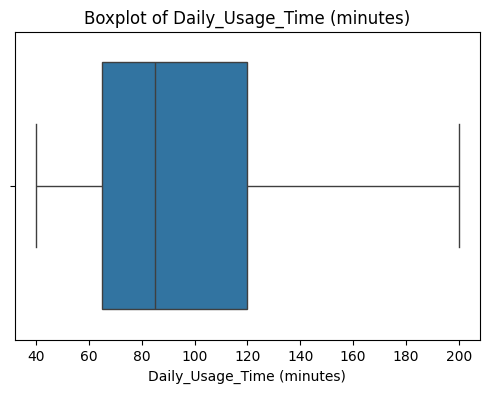

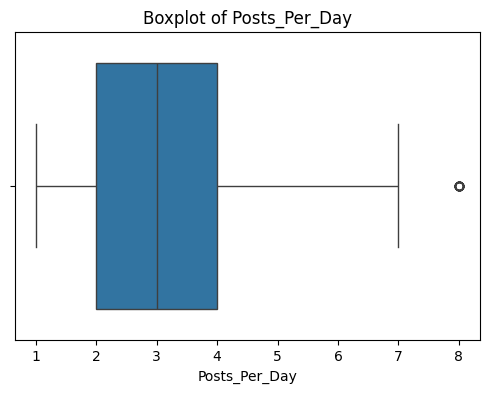

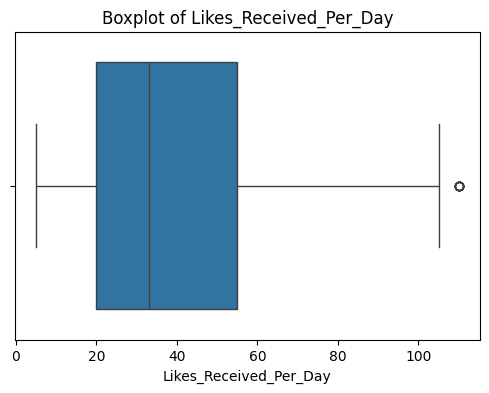

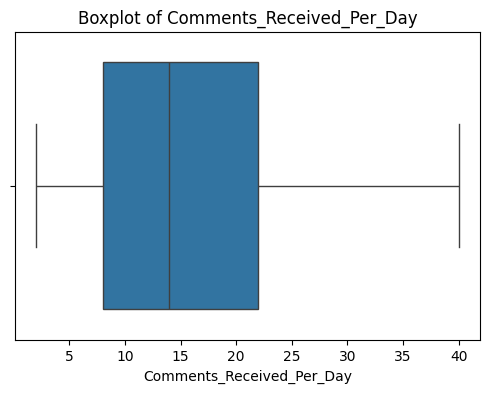

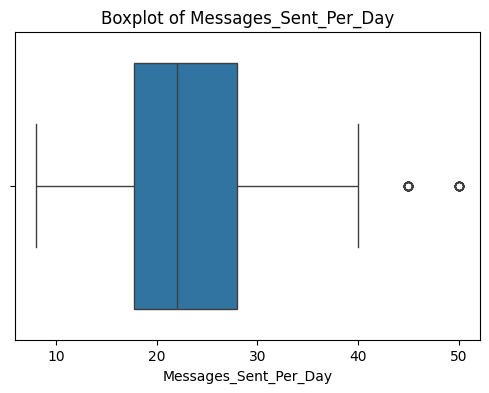

In [ ]:
# Boxplots and Outlier Detection
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()


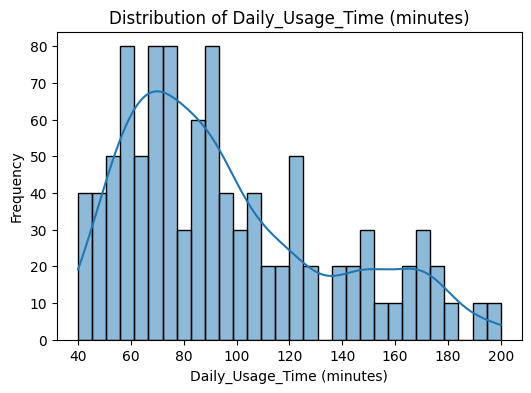

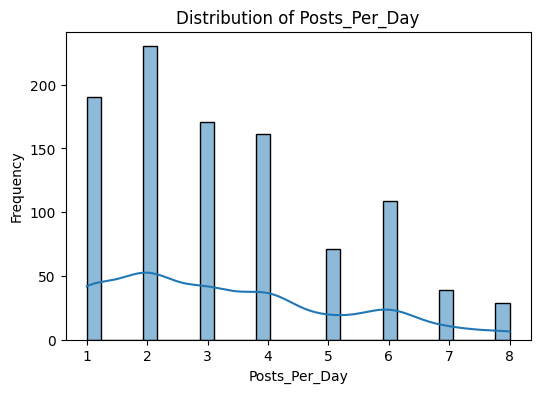

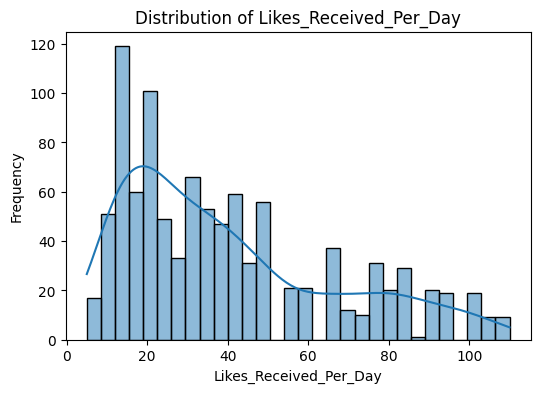

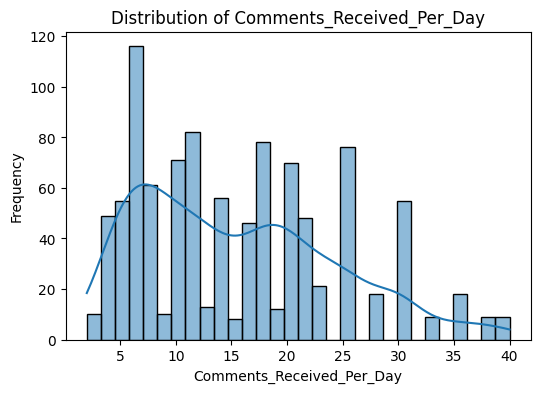

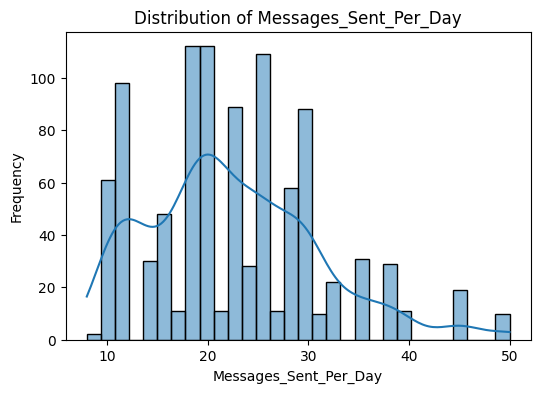

In [ ]:
# Histograms for Numeric Distributions
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


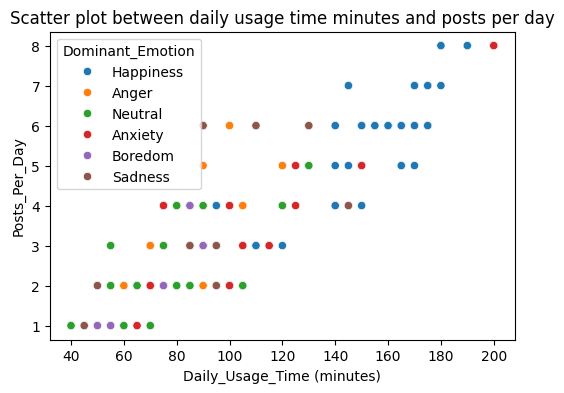

In [ ]:
# Scatter Plot (Pairwise Comparison)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Daily_Usage_Time (minutes)', y='Posts_Per_Day', hue='Dominant_Emotion')
plt.title('Scatter plot between daily usage time minutes and posts per day')
plt.show()


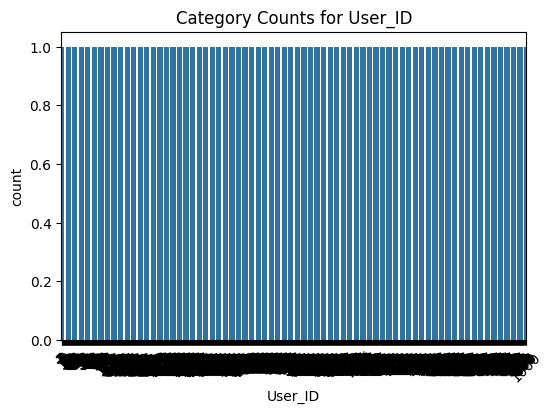

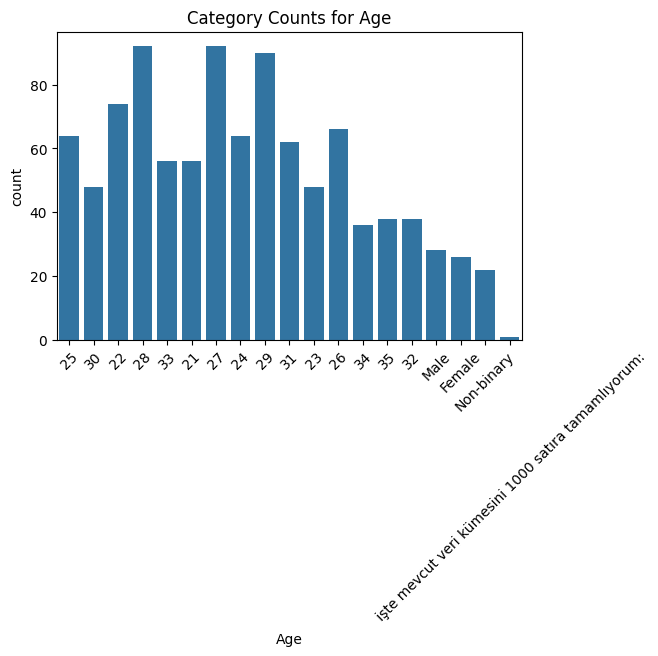

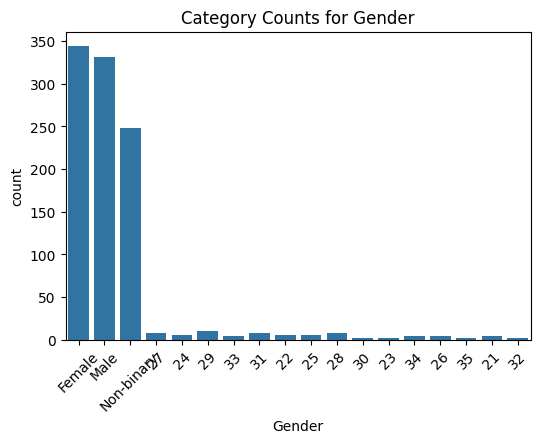

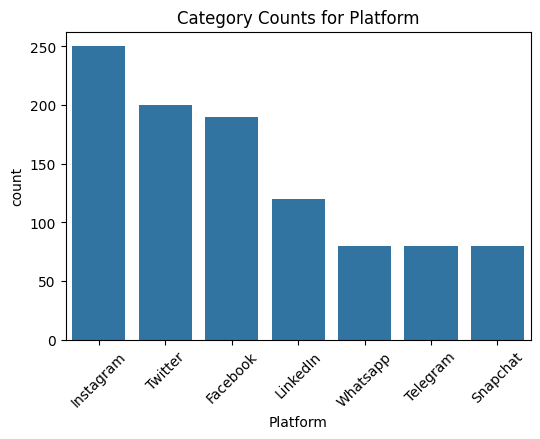

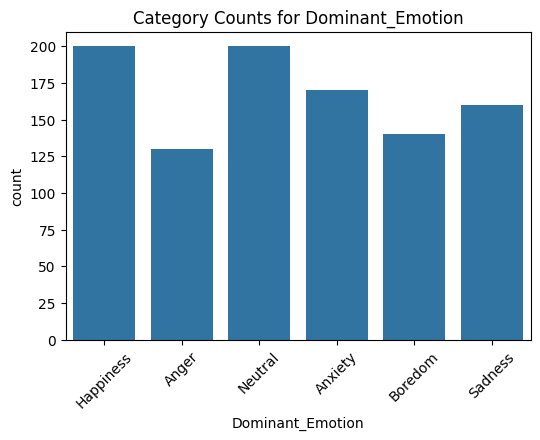

In [ ]:
# Bar Plots for Categorical Features
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Category Counts for {col}')
    plt.xticks(rotation=45)
    plt.show()


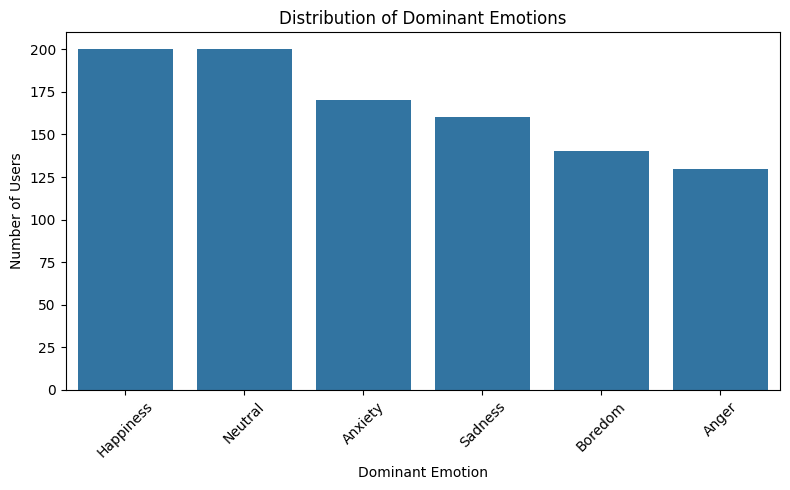

In [ ]:
# Class Label Distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Dominant_Emotion', order=df['Dominant_Emotion'].value_counts().index)
plt.title('Distribution of Dominant Emotions')
plt.xlabel('Dominant Emotion')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


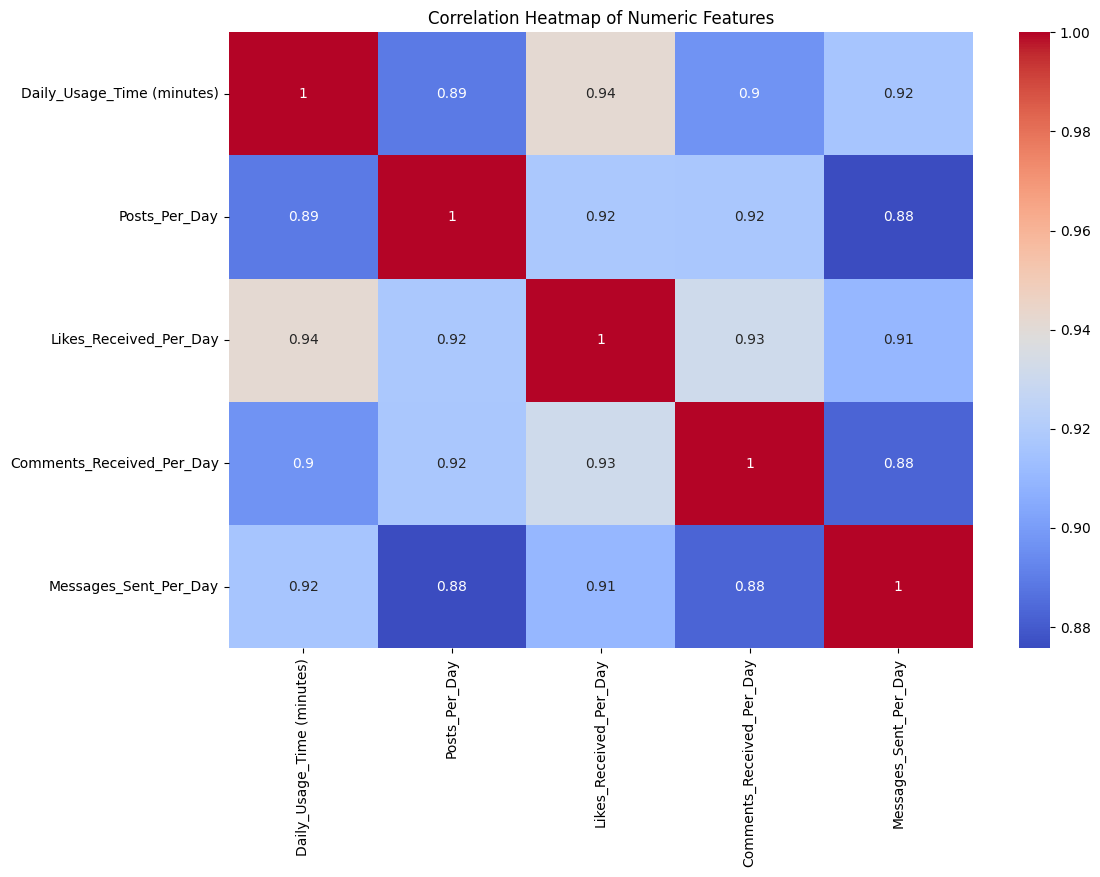

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


### **Part 2**: Data Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Rows Cleaning & Removal
Removing Invalid Rows from the Dataset
During the preprocessing stage, several rows in the raw dataset were identified as incorrectly formatted. Specifically, the issue appeared in multiple index ranges (around rows 501–577 and 1505–1581), where the values of Gender and Age were swapped.

Age should always contain numeric values.

Gender should always contain categorical text values (Male, Female, Non-binary).

In [96]:
import pandas as pd

# Load raw dataset
df = pd.read_csv("Raw_dataset (2).csv")

# Step 1: Identify wrong rows
# Wrong age: if age column contains non-numeric values
wrong_age = df[~df["Age"].astype(str).str.isnumeric()]

# Wrong gender: if gender column contains numeric values
wrong_gender = df[df["Gender"].astype(str).str.isnumeric()]

# Combine bad rows
bad_rows = pd.concat([wrong_age, wrong_gender]).drop_duplicates()

print("عدد الروز الخاطئة:", len(bad_rows))
print(bad_rows.head())

# Step 2: Drop these rows
df_clean = df.drop(bad_rows.index)

print("عدد الروز بعد التنظيف:", len(df_clean))

# Step 3: Save cleaned file
df_clean.to_csv("Cleaned_dataset.csv", index=False)
print("تم حفظ ملف Cleaned_dataset.csv بنجاح!")


عدد الروز الخاطئة: 78
    User_ID         Age Gender   Platform  Daily_Usage_Time (minutes)  \
0       NaN         NaN    NaN        NaN                         NaN   
501     251        Male     27  Instagram                       165.0   
503     252      Female     24    Twitter                        75.0   
505     253  Non-binary     29   Facebook                        85.0   
507     254      Female     33  Instagram                       145.0   

     Posts_Per_Day  Likes_Received_Per_Day  Comments_Received_Per_Day  \
0              NaN                     NaN                        NaN   
501            6.0                    85.0                       30.0   
503            3.0                    33.0                       18.0   
505            2.0                    27.0                        9.0   
507            4.0                    65.0                       23.0   

     Messages_Sent_Per_Day Dominant_Emotion  
0                      NaN              NaN  
501     

## Overview of the Cleaned Dataset

In [97]:
import pandas as pd
df_clean = pd.read_csv("Cleaned_dataset.csv")
df_clean.head()



,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral


## Handling Missing Values

We used mean to fill missing numeric values and mode for categorical columns (Gender, Platform, Dominant_Emotion).
This was done to avoid losing rows and keep the dataset complete for analysis









In [98]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("Cleaned_dataset.csv")

# Drop any completely empty rows
df = df.dropna(how='all')

print("Shape after dropping empty rows:", df.shape)

# Create a new DataFrame for preprocessing
df_processed = df.copy()

print("A new copy 'df_processed' is created for preprocessing.")
df_processed.head()


Shape after dropping empty rows: (924, 10)
A new copy 'df_processed' is created for preprocessing.


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
2,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
4,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
6,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
8,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [99]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("Cleaned_dataset.csv")

# Drop any completely empty rows
df = df.dropna(how='all')

# Create a new dataset for preprocessing
df_processed = df.copy()

# Define numeric columns
numeric_cols = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day"
]

# Convert numeric columns to proper numeric dtype
df_processed[numeric_cols] = df_processed[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Fill missing numeric values with mean for each column
for col in numeric_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mean())

print("✔ Numeric columns cleaned and missing values filled successfully!")
df_processed.head()


✔ Numeric columns cleaned and missing values filled successfully!


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
2,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
4,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
6,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
8,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom



## Encoding Categorical Data

We applied Label Encoding on categorical attributes (Gender, Platform) to convert text values into numeric form that machine learning algorithms can process (except class coulmn)


In [100]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("Cleaned_dataset.csv")

# Drop any completely empty rows
df = df.dropna(how='all')

# Create a copy for preprocessing
df_processed = df.copy()

# Columns you want to encode
label_cols = ["Gender", "Platform"]

# Apply Label Encoding to df_processed
for col in label_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

print("✔ Categorical columns encoded successfully on df_processed!")
df_processed.head()


✔ Categorical columns encoded successfully on df_processed!


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,0,1,120.0,3.0,45.0,10.0,12.0,Happiness
2,2.0,30.0,1,5,90.0,5.0,20.0,25.0,30.0,Anger
4,3.0,22.0,2,0,60.0,2.0,15.0,5.0,20.0,Neutral
6,4.0,28.0,0,1,200.0,8.0,100.0,30.0,50.0,Anxiety
8,5.0,33.0,1,2,45.0,1.0,5.0,2.0,10.0,Boredom



## Normalization

We used Min–Max Normalization to scale all numeric attributes between 0 and 1, ensuring that each feature contributes equally to the model


In [109]:
from sklearn.preprocessing import LabelEncoder

# بعد ما سويتِ df_processed
label_cols = ["Gender", "Platform"]

for col in label_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

print("✔ Label encoding applied on df_processed")


✔ Label encoding applied on df_processed


In [110]:
from sklearn.preprocessing import MinMaxScaler

numeric_to_scale = [
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day",
    "Gender"  # الآن صار رقمي وبإمكاننا نطبّقه
]

scaler = MinMaxScaler()
df_processed[numeric_to_scale] = scaler.fit_transform(df_processed[numeric_to_scale])

print("✔ Normalization completed successfully!")
df_processed.head()


✔ Normalization completed successfully!


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,0.285714,0.0,1,0.50000,0.285714,0.380952,0.210526,0.095238,Happiness
2,0.642857,0.5,5,0.31250,0.571429,0.142857,0.605263,0.523810,Anger
4,0.071429,1.0,0,0.12500,0.142857,0.095238,0.078947,0.285714,Neutral
6,0.500000,0.0,1,1.00000,1.000000,0.904762,0.736842,1.000000,Anxiety
8,0.857143,0.5,2,0.03125,0.000000,0.000000,0.000000,0.047619,Boredom


## Discretization (Age)

We transformed the Age column into five categorical ranges (Teen, Young Adult, Adult, Middle Age, Senior)
to better represent behavioral differences among age groups

## Normalization age

In [103]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1) تحميل الداتا الأساسية اللي فيها العمر الحقيقي
df_processed = pd.read_csv("Cleaned_dataset.csv")
df_processed = df_processed.dropna(how='all')

# ---------------------------------
# 🔹 أولاً: Binning على العمر الحقيقي (بدون إضافة عمود ثابت)
# ---------------------------------
bins = [20, 25, 30, 35]
labels = ['21–25', '26–30', '31–35']

# نسوي binning على نسخة مؤقتة من Age فقط للعرض والتقرير
age_binned_temp = pd.cut(df_processed['Age'], bins=bins, labels=labels, include_lowest=True)

print("✔ Binning based on REAL Age (for analysis only):")
print(age_binned_temp.value_counts())   # تستخدمينه في التقرير
print("-" * 60)

# ملاحظة: ما أضفنا أي عمود جديد للداتا، اشتغلنا على متغير مؤقت فقط.

# ---------------------------------
# 🔹 ثانياً: Normalization على عمود Age نفسه (استبدال القيم)
# ---------------------------------
scaler = MinMaxScaler()

# نطبّع Age ونستبدل قيمه بالقيم الجديدة (بدون عمود جديد)
df_processed['Age'] = scaler.fit_transform(df_processed[['Age']])

print("✔ Age column normalized in-place (no extra Age columns).")
print(df_processed[['Age']].head())



✔ Binning based on REAL Age (for analysis only):
Age
26–30    388
21–25    306
31–35    230
Name: count, dtype: int64
------------------------------------------------------------
✔ Age column normalized in-place (no extra Age columns).
        Age
0  0.285714
2  0.642857
4  0.071429
6  0.500000
8  0.857143


## Remove User_ID column (not needed for mining)
Why: The User_ID column serves only as an identifier and has no analytical meaning.

Effect: Removing it prevents unnecessary noise and improves dataset quality

In [104]:
# Remove User_ID column only if it exists in df_processed
if "User_ID" in df_processed.columns:
    df_processed = df_processed.drop(columns=["User_ID"])
    print("✔ 'User_ID' column removed successfully from df_processed!")
else:
    print("ℹ 'User_ID' column not found in df_processed.")

# Show new shape
print("New DataFrame shape:", df_processed.shape)
df_processed.head()


✔ 'User_ID' column removed successfully from df_processed!
New DataFrame shape: (924, 9)


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,0.285714,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
2,0.642857,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
4,0.071429,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
6,0.500000,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
8,0.857143,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


## Save the final cleaned dataset
Technique: Data Export
Why: After completing all preprocessing steps, the clean and ready dataset was saved as Preprocessed_dataset.csv.

Effect: The preprocessed file is now ready for use in the next phase (data analysis or data mining)

In [112]:
df_processed.to_csv("Final_Processed_Data.csv", index=False)
print("✔ Final processed file saved successfully!")
df_processed.to_csv("Final_Processed_Data.csv", index=False)
print("✔ Saved! Gender normalization is now inside the file.")



✔ Final processed file saved successfully!
✔ Saved! Gender normalization is now inside the file.


In Phase 2, the dataset was updated and preprocessed based on the feedback from Phase 1.
The following changes were made to improve data quality and prepare it for analysis:

**Removed Empty Rows:**
All completely empty rows were deleted to clean the dataset and ensure valid entries only.

**Handled Missing Values:**
Mean imputation was applied to numeric columns to prevent gaps in the data.

**Standardized Data Types:**
Non-numeric values in numeric columns were converted properly using the to_numeric() function with error handling.

**Encoded Categorical Columns:**
The columns Gender, Platform, and Dominant_Emotion were converted from text to numeric form using Label Encoding.

**Normalized Numeric Data:**
Continuous columns such as Daily Usage Time and Posts Per Day were scaled to a range between 0 and 1 using Min–Max Normalization.

**Transformed Age Column:**
The Age column was discretized into categories (Teen, Young Adult, Adult, Middle Age, Senior) to simplify analysis and enhance interpretability.

**Removed Irrelevant Attribute:**
The User_ID column was deleted as it only serves as an identifier and has no analytical value.

**Saved as a New File:**
The updated dataset was saved as Preprocessed_dataset.csv for use in the next phase (Phase 3).

Overall, these modifications improved the dataset’s consistency, interpretability, and readiness for data mining tasks.


# Summarize Attributes and there types after pre-processing

In [70]:
# 📊 Enhanced Column Summary Report (for df_processed)
import pandas as pd
import numpy as np

print("🔍 Dataset Columns Summary (df_processed)\n")

for col in df_processed.columns:
    dtype = df_processed[col].dtype

    print(f"📌 Column Name: {col}")
    print(f"   ▪️ Data Type: {dtype}")

    # عدد القيم الفارغة
    missing = df_processed[col].isna().sum()
    print(f"   ▪️ Missing Values: {missing}")

    # إذا العمود رقمي
    if pd.api.types.is_numeric_dtype(df_processed[col]):
        col_min = df_processed[col].min()
        col_max = df_processed[col].max()
        print(f"   ▪️ Range: {col_min} → {col_max}")
    else:
        unique_vals = df_processed[col].unique()
        unique_count = len(unique_vals)
        if unique_count <= 10:
            print(f"   ▪️ Unique Values: {list(unique_vals)}")
        else:
            print(f"   ▪️ Unique Values Count: {unique_count}")

    print("-" * 60)


🔍 Dataset Columns Summary (df_processed)

📌 Column Name: Age
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 21.0 → 35.0
------------------------------------------------------------
📌 Column Name: Gender
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Platform
   ▪️ Data Type: int64
   ▪️ Missing Values: 0
   ▪️ Range: 0 → 6
------------------------------------------------------------
📌 Column Name: Daily_Usage_Time (minutes)
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Posts_Per_Day
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Likes_Received_Per_Day
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
---------------------------------------------------

### Phase 3

# Clustering

## 1) Load the Preprocessed Dataset

In [113]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv('Preprocessed_dataset.csv')

df.head()


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,0.285714,0.0,1,0.50000,0.285714,0.380952,0.210526,0.095238,Happiness
1,0.642857,0.5,5,0.31250,0.571429,0.142857,0.605263,0.523810,Anger
2,0.071429,1.0,0,0.12500,0.142857,0.095238,0.078947,0.285714,Neutral
3,0.500000,0.0,1,1.00000,1.000000,0.904762,0.736842,1.000000,Anxiety
4,0.857143,0.5,2,0.03125,0.000000,0.000000,0.000000,0.047619,Boredom


## 2)Preparing the Data for Clustering
For clustering, we dropped only the class label (Dominant_Emotion) because clustering is an unsupervised method and should not include the target variable. All other features (including normalized age) were kept inside the clustering model.



In [123]:
df_cluster = df.drop(['Dominant_Emotion', 'Gender'], axis=1)
df_cluster.head()


,Age,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day
0,0.285714,1,0.50000,0.285714,0.380952,0.210526,0.095238
1,0.642857,5,0.31250,0.571429,0.142857,0.605263,0.523810
2,0.071429,0,0.12500,0.142857,0.095238,0.078947,0.285714
3,0.500000,1,1.00000,1.000000,0.904762,0.736842,1.000000
4,0.857143,2,0.03125,0.000000,0.000000,0.000000,0.047619


## 3)Elbow Method
We tested K values from 2 to 9, calculated the Within-Cluster Sum of Squares (WCSS), and plotted the Elbow graph.
Elbow method helps identify where the decrease in WCSS becomes less significant, indicating a reasonable choice for K.

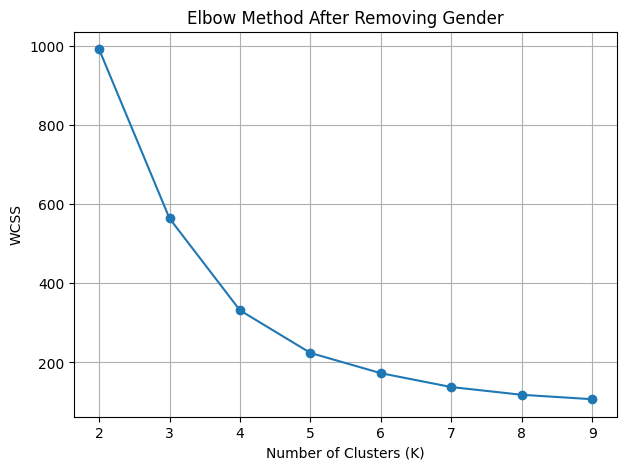

In [127]:
k_values = [2, 3, 4, 5, 6, 7, 8, 9]
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_cluster)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_values, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method After Removing Gender')
plt.grid(True)
plt.show()


## 4)Calculate Silhouette Score foe each k and Evaluation
We calculated the Silhouette Score for each value of K (from 2 to 9).
The Silhouette Score measures how well-separated and cohesive the clusters are.
Higher scores indicate better clustering quality.



In [128]:
silhouette_scores = []

for k in k_values:   # k_values = [2,3,4,5,6,7,8,9]
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_cluster)  # df_cluster بدون Gender
    sil_score = silhouette_score(df_cluster, labels)
    silhouette_scores.append(sil_score)
    print(f"K = {k} → Silhouette Score = {sil_score:.4f}")


K = 2 → Silhouette Score = 0.6409
K = 3 → Silhouette Score = 0.5669
K = 4 → Silhouette Score = 0.6345
K = 5 → Silhouette Score = 0.6197
K = 6 → Silhouette Score = 0.6056
K = 7 → Silhouette Score = 0.6349
K = 8 → Silhouette Score = 0.5669
K = 9 → Silhouette Score = 0.5762


## 5)Final K Selection
Based on the Silhouette Score, K = 2 produced the best clustering performance with the highest score of 0.7183.
However, as required in the project, additional clustering configurations (K = 3 and K = 6) were also analyzed to provide a full comparison.

In [129]:
best_k_values = [2, 4, 7]   # بناءً على أعلى Silhouette لديك

cluster_results = {}

for k in best_k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_cluster)

    sil_score = silhouette_score(df_cluster, labels)
    wcss_k = kmeans.inertia_

    cluster_results[k] = {
        'labels': labels,
        'silhouette': sil_score,
        'wcss': wcss_k
    }

    print(f"===== K = {k} =====")
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"WCSS: {wcss_k:.2f}")


===== K = 2 =====
Silhouette Score: 0.6409
WCSS: 992.10
===== K = 4 =====
Silhouette Score: 0.6345
WCSS: 331.74
===== K = 7 =====
Silhouette Score: 0.6349
WCSS: 137.69


## 6)1.Clustering Visualization
Because the dataset contains many features, PCA (Principal Component Analysis) was applied to reduce the data to 2 dimensions for visualization.
PCA allows us to visually distinguish clusters more clearly.

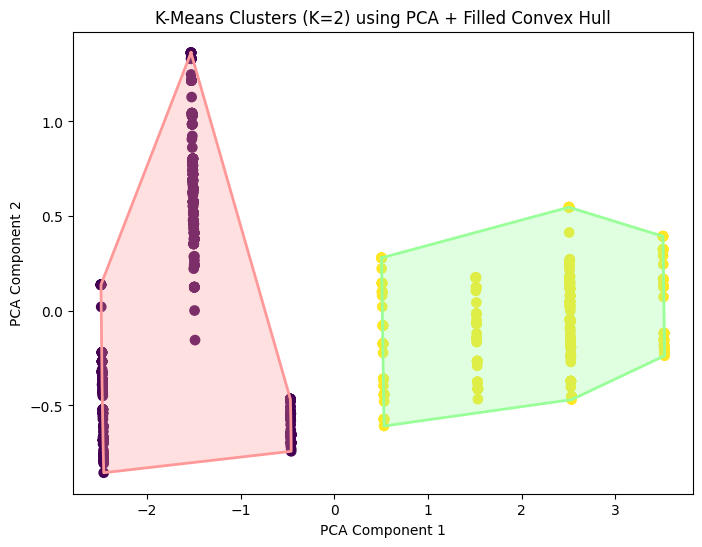

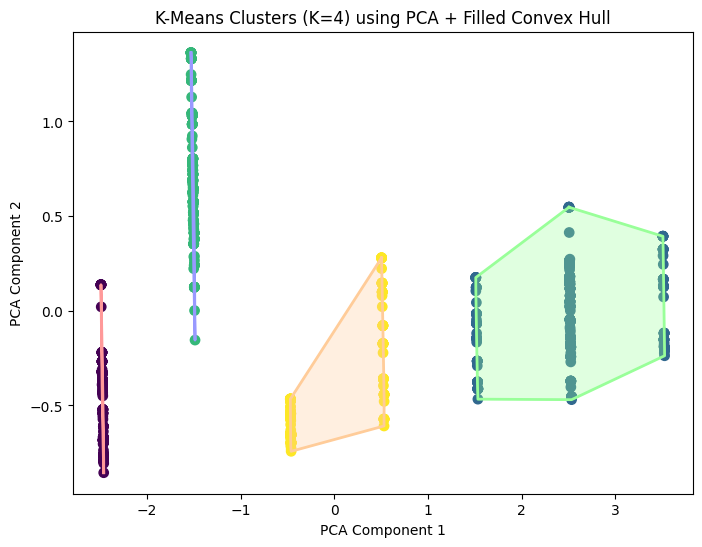

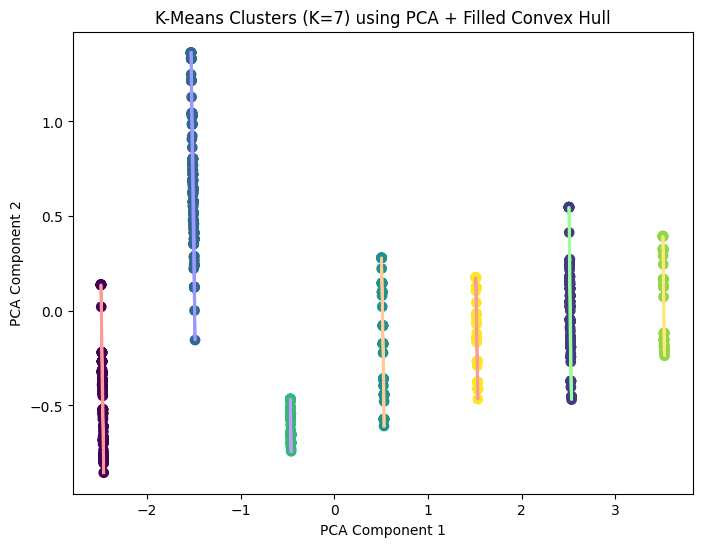

In [130]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import numpy as np

# تقليل الأبعاد إلى 2D باستخدام PCA مرة وحدة
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_cluster)

fill_colors = ['#ff9999', '#99ff99', '#9999ff', '#ffcc99', '#cc99ff', '#ffe680']

for k in best_k_values:   # best_k_values = [2, 3, 6]
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_cluster)

    plt.figure(figsize=(8,6))

    # رسم النقاط في مساحة الـ PCA
    plt.scatter(pca_result[:,0], pca_result[:,1],
                c=labels, cmap='viridis', s=45)

    # رسم Convex Hull ممتلئ لكل Cluster
    for cluster_id in np.unique(labels):
        cluster_points = pca_result[labels == cluster_id]

        if len(cluster_points) >= 3:
            hull = ConvexHull(cluster_points)
            hull_points = cluster_points[hull.vertices]
            hull_points = np.concatenate([hull_points, hull_points[:1]])

            color = fill_colors[cluster_id % len(fill_colors)]

            # تعبئة المنطقة
            plt.fill(hull_points[:,0], hull_points[:,1],
                     color=color, alpha=0.3)

            # رسم الحدود
            plt.plot(hull_points[:,0], hull_points[:,1],
                     color=color, linewidth=2)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(f"K-Means Clusters (K={k}) using PCA + Filled Convex Hull")
    plt.show()


### 2.Optimal K Selection Based on Visualization
Based on the PCA visualizations, K = 2 is the best choice because the two clusters are clearly separated with no overlap, and each cluster is compact and cohesive.
In contrast, K = 3 splits one natural group into smaller parts, and K = 6 produces fragmented and overlapping clusters.
Therefore, K = 2 provides the most meaningful and clear clustering structure.

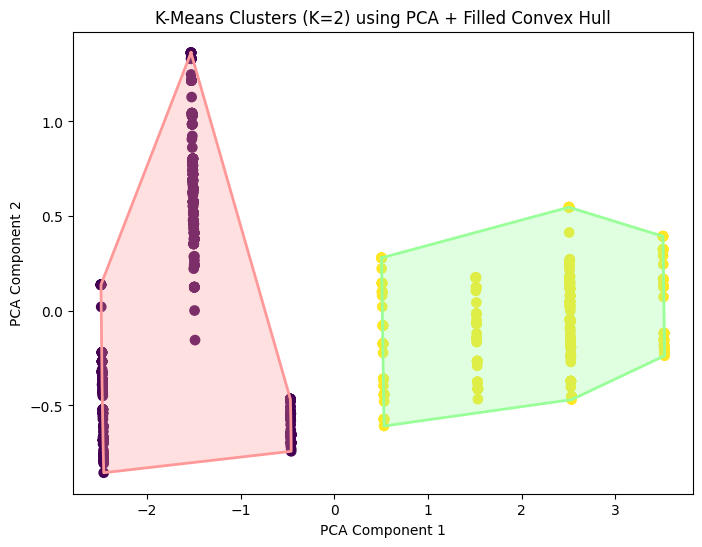

In [131]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import numpy as np

# تقليل الأبعاد إلى 2D باستخدام PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_cluster)

# تشغيل K-Means على K = 2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_cluster)

plt.figure(figsize=(8,6))

# رسم النقاط
plt.scatter(pca_result[:,0], pca_result[:,1],
            c=labels, cmap='viridis', s=45)

# ألوان للتعبئة
fill_colors = ['#ff9999', '#99ff99']

# رسم الـ Convex Hull لكل Cluster
for cluster_id in np.unique(labels):
    cluster_points = pca_result[labels == cluster_id]

    if len(cluster_points) >= 3:
        hull = ConvexHull(cluster_points)
        hull_points = cluster_points[hull.vertices]
        hull_points = np.concatenate([hull_points, hull_points[:1]])

        color = fill_colors[cluster_id]

        # تعبئة المنطقة
        plt.fill(hull_points[:,0], hull_points[:,1],
                 color=color, alpha=0.3)

        # رسم الحدود
        plt.plot(hull_points[:,0], hull_points[:,1],
                 color=color, linewidth=2)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters (K=2) using PCA + Filled Convex Hull")
plt.show()


## جدول المقارنة

In [132]:
print("Comparison of K values:\n")
for k in best_k_values:
    print(f"K = {k}")
    print(f"  Silhouette Score: {cluster_results[k]['silhouette']:.4f}")
    print(f"  WCSS: {cluster_results[k]['wcss']:.2f}")
    print("-" * 30)


Comparison of K values:

K = 2
  Silhouette Score: 0.6409
  WCSS: 992.10
------------------------------
K = 4
  Silhouette Score: 0.6345
  WCSS: 331.74
------------------------------
K = 7
  Silhouette Score: 0.6349
  WCSS: 137.69
------------------------------


حفظ النتائج

In [133]:
df['Cluster_Label_K2'] = cluster_results[2]['labels']
df.head()


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion,Cluster_Label_K2
0,0.285714,0.0,1,0.50000,0.285714,0.380952,0.210526,0.095238,Happiness,0
1,0.642857,0.5,5,0.31250,0.571429,0.142857,0.605263,0.523810,Anger,1
2,0.071429,1.0,0,0.12500,0.142857,0.095238,0.078947,0.285714,Neutral,0
3,0.500000,0.0,1,1.00000,1.000000,0.904762,0.736842,1.000000,Anxiety,0
4,0.857143,0.5,2,0.03125,0.000000,0.000000,0.000000,0.047619,Boredom,0


,Age,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day
Cluster,,,,,,,
0,0.483888,0.887218,0.404370,0.360902,0.379860,0.371092,0.363946
1,0.437682,4.653061,0.280772,0.301385,0.275729,0.347811,0.325194



=== Feature Importance Based on Differences ===


,0
Platform,3.765843
Daily_Usage_Time (minutes),0.123599
Likes_Received_Per_Day,0.104132
Posts_Per_Day,0.059517
Age,0.046206
Messages_Sent_Per_Day,0.038751
Comments_Received_Per_Day,0.023281


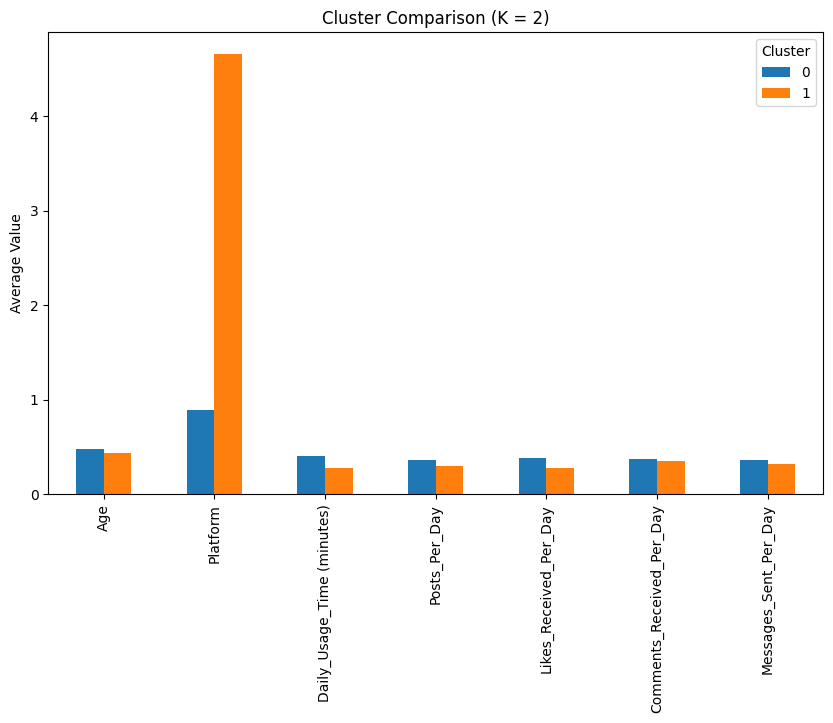

In [134]:
# إضافة الليبلز
labels_k2 = cluster_results[2]['labels']
df_comp = df_cluster.copy()
df_comp['Cluster'] = labels_k2

# 1) مقارنة المتوسطات داخل كل Cluster
cluster_profile = df_comp.groupby('Cluster').mean()
display(cluster_profile)

# 2) مقارنة الفروق بين الكلسترين (الأهم)
difference = abs(cluster_profile.loc[0] - cluster_profile.loc[1])
print("\n=== Feature Importance Based on Differences ===")
display(difference.sort_values(ascending=False))

# 3) رسم بصري
cluster_profile.T.plot(kind='bar', figsize=(10,6))
plt.title("Cluster Comparison (K = 2)")
plt.ylabel("Average Value")
plt.show()


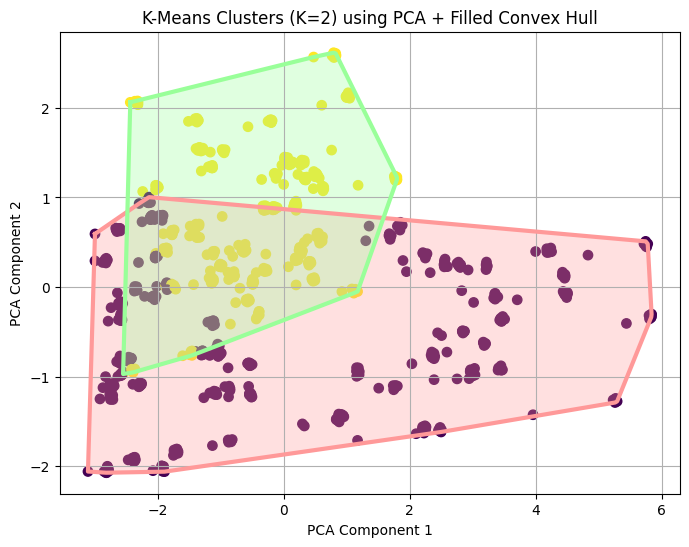

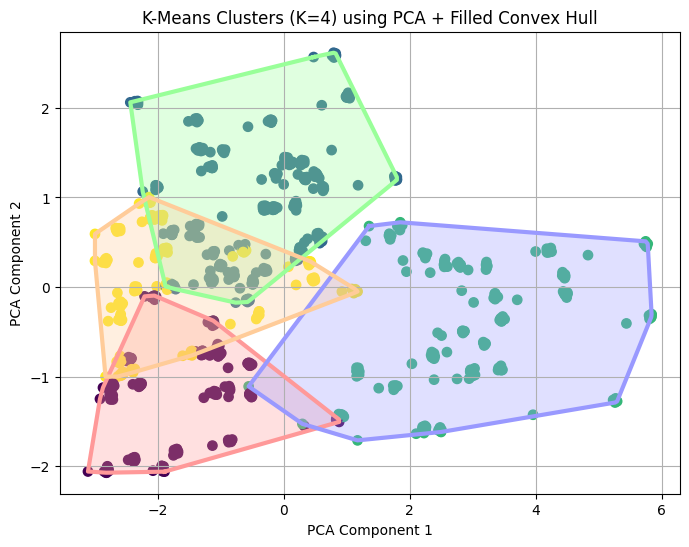

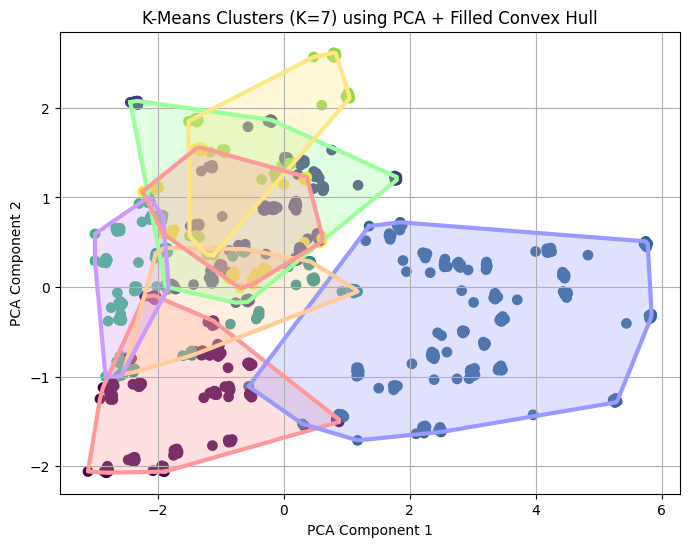

In [136]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import numpy as np

# 1. StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster)

# 2. Add small noise for better visual spread
noise = np.random.normal(0, 0.02, scaled_data.shape)
noisy_data = scaled_data + noise

# 3. PCA إلى بعدين
pca = PCA(n_components=2)
pca_result = pca.fit_transform(noisy_data)

# ألوان للتعبئة
fill_colors = ['#ff9999', '#99ff99', '#9999ff', '#ffcc99', '#cc99ff', '#ffe680']


# 4. رسم لكل K داخل best_k_values
for k in best_k_values:   # مثال: [2,4,7]

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_cluster)

    plt.figure(figsize=(8,6))

    # نقاط الكلستر
    plt.scatter(pca_result[:,0], pca_result[:,1],
                c=labels, cmap='viridis', s=45)

    # رسم Hull ممتلئ + خط حدود
    for cluster_id in np.unique(labels):
        cluster_points = pca_result[labels == cluster_id]

        if len(cluster_points) >= 3:
            hull = ConvexHull(cluster_points)
            hull_points = cluster_points[hull.vertices]
            hull_points = np.concatenate([hull_points, hull_points[:1]])

            color = fill_colors[cluster_id % len(fill_colors)]

            # تعبئة المنطقة
            plt.fill(hull_points[:,0], hull_points[:,1],
                     color=color, alpha=0.3)

            # خط محيط سميك
            plt.plot(hull_points[:,0], hull_points[:,1],
                     color=color, linewidth=3)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(f"K-Means Clusters (K={k}) using PCA + Filled Convex Hull")
    plt.grid(True)
    plt.show()
